In [23]:
import argparse
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
import matplotlib.pyplot as plt

In [24]:
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor


def train_KNN(xTrain, yTrain):
    model = KNeighborsRegressor(metric="manhattan", n_neighbors=20, p=1, weights="uniform")
    model.fit(xTrain, yTrain)
    return model

def train_DT(xTrain, yTrain):
    model = DecisionTreeRegressor(criterion="friedman_mse", min_samples_leaf=4, min_samples_split=1, splitter="random")
    model.fit(xTrain, yTrain)
    return model

def train_Linear(xTrain, yTrain):
    model = LinearRegression(fit_intercept=False)
    model.fit(xTrain, yTrain)
    return model
def train_Ridge(xTrain, yTrain):
    model = Ridge(solver="auto", alpha=0.001, random_state=42)
    model.fit(xTrain, yTrain)
    return model

def train_Lasso(xTrain, yTrain):
    model = Lasso(alpha=0.001, random_state=42)
    model.fit(xTrain, yTrain)
    return model

def dayhour_split():
    dayhour = pd.read_csv("Preprocessed-gapa.csv")
    rng = np.random.default_rng(seed=42)
    N = len(dayhour)
    permuted_indices = rng.permutation(N)
    dayhour = dayhour.iloc[permuted_indices]
    dayhour = dayhour["dayhour"]
    split = int(N*0.8)
    train_dayhour = dayhour[:split]
    test_dayhour = dayhour[split:]
    return train_dayhour, test_dayhour


0.025673864383940228
0.3789392503278417


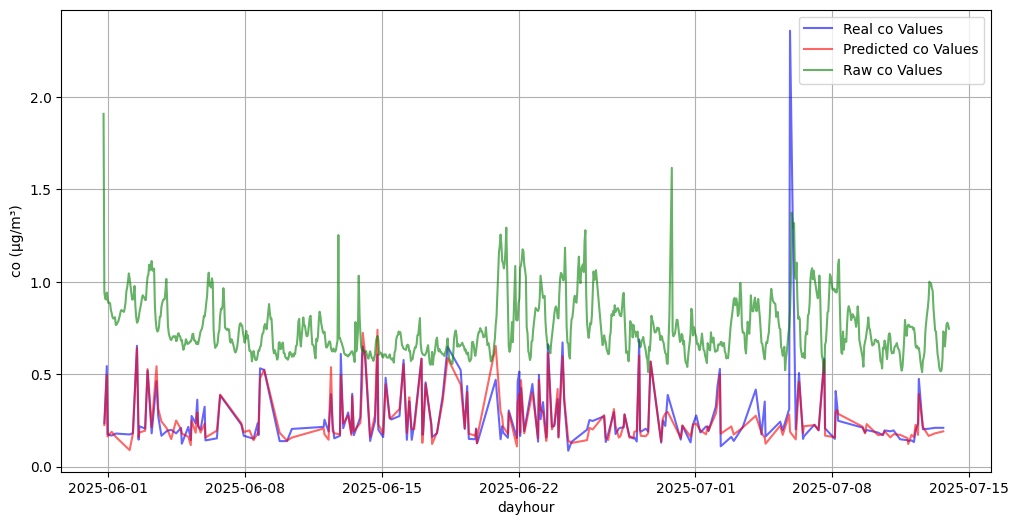

In [25]:
xTrain = pd.read_csv("xTrain.csv")
yTrain = pd.read_csv("yTrain.csv")
xTest = pd.read_csv("xTest.csv")
yTest = pd.read_csv("yTest.csv")
# model = train_KNN(xTrain, yTrain)
#model = train_DT(xTrain, yTrain)
# model = train_Linear(xTrain, yTrain)
model = train_Ridge(xTrain, yTrain)
# model = train_Lasso(xTrain, yTrain)

y_pred = model.predict(xTest).flatten()
mse = mean_squared_error(yTest, y_pred)
r2 = r2_score(yTest, y_pred)
print(mse)
print(r2)

# Get the dayhours
train_dayhour, test_dayhour = dayhour_split()

# Make sure test_dayhour matches the length of yTest
test_dayhour = test_dayhour.reset_index(drop=True)
yTest = yTest.reset_index(drop=True)

# Add dayhour to dataframes
yTest["dayhour"] = test_dayhour.values
yPrediction = pd.DataFrame({
    "dayhour": test_dayhour.values,
    "co": y_pred
})

# Sort by dayhour for plotting
yTest = yTest.sort_values("dayhour").reset_index(drop=True)
yPrediction = yPrediction.sort_values("dayhour").reset_index(drop=True)

# Convert dayhour to datetime for better plotting
yTest["dayhour"] = pd.to_datetime(yTest["dayhour"])
yPrediction["dayhour"] = pd.to_datetime(yPrediction["dayhour"])


raw_QAQ = pd.read_csv("Preprocessed-00589.csv")
raw_QAQ["dayhour"] = pd.to_datetime(raw_QAQ["dayhour"])
raw_QAQ["co"] = raw_QAQ["co"] / 1000
plt.figure(figsize=(12, 6))
plt.plot(yTest["dayhour"], yTest["co"], label="Real co Values", color='blue', alpha=0.6)
plt.plot(yPrediction["dayhour"], yPrediction["co"], label="Predicted co Values", color='red', alpha=0.6)
plt.plot(raw_QAQ["dayhour"], raw_QAQ["co"], label="Raw co Values", color='green', alpha=0.6)
plt.xlabel('dayhour')
plt.ylabel(f'co (μg/m\u00B3)')
plt.legend()
plt.grid()
plt.show()